<a href="https://colab.research.google.com/github/Mikolaj-13/lecture1/blob/main/pum5_regresjanieliniowa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, HuberRegressor, RANSACRegressor, TheilSenRegressor, SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import PredictionErrorDisplay

In [63]:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Salary Data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "rkiattisak/salaly-prediction-for-beginer",
  file_path,
)

print("First 5 records:", df.head())

/tmp/ipykernel_8287/2150386848.py:9: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'salaly-prediction-for-beginer' dataset.
First 5 records:     Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  


In [64]:
df.info()

le = LabelEncoder()

for column in ['Gender', 'Education Level', 'Job Title']:
  if column in df.columns:
    df[column] = le.fit_transform(df[column])

print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB
    Age  Gender  Education Level  Job Title  Years of Experience    Salary
0  32.0       1                0        159                  5.0   90000.0
1  28.0       0                1         17                  3.0   65000.0
2  45.0       1                2        130                 15.0  150000.0
3  36.0       0                0        101                  7.0   60000.0
4  52.0       1                1         22                 20.0  20

In [65]:
df.dropna(inplace=True)
y = df['Salary']
X = df.drop('Salary', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


Zbuduj model benchmarkowy - zwykłą regresję liniową

In [66]:
regressor = LinearRegression().fit(X_train, y_train)
print(f"Współczynniki: {regressor.coef_}")
print(f"Wyraz wolny: {regressor.intercept_}")
print(f" R^2 {regressor.score(X_train, y_train)}")
print(f"Średni błąd absolutny z treningu: {mean_absolute_error(y_train, regressor.predict(X_train)):.2f}")

y_pred = regressor.predict(X_test)
print(f"Średni błąd kwadratowy: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Średni błąd absolutny: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Wyjaśniona wariancja: {explained_variance_score(y_test, y_pred):.2f}")

Współczynniki: [ 3400.65625     7384.17507075 15289.75305615    38.30848175
  2155.12465162]
Wyraz wolny: -63972.08387966572
 R^2 0.9043289032978942
Średni błąd absolutny z treningu: 11171.01
Średni błąd kwadratowy: 252493731.92
Średni błąd absolutny: 11377.18
Wyjaśniona wariancja: 0.89


Sprawdź czy w danych występuje współliniowość współczynnikiem VIF

In [67]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# calculating VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)

X = X.drop("Age", axis=1)

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)

               feature        VIF
0                  Age  15.191310
1               Gender   2.059767
2      Education Level   2.403316
3            Job Title   4.865563
4  Years of Experience   9.479247
               feature       VIF
0               Gender  1.819647
1      Education Level  2.379329
2            Job Title  2.798903
3  Years of Experience  4.147387


Spróbuj poprawić wynik używając regresji LASSO

In [68]:
df.dropna(inplace=True)
y = df['Salary']
X = df.drop('Salary', axis=1)
X = X.drop("Age", axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

lasso_regressor = Lasso(alpha=0.1) # You can tune the alpha value
lasso_regressor.fit(X_train, y_train)

print(f"Współczynniki LASSO: {lasso_regressor.coef_}")
print(f"Wyraz wolny LASSO: {lasso_regressor.intercept_}")
print(f"R^2 LASSO z treningu: {lasso_regressor.score(X_train, y_train)}")
print(f"Średni błąd absolutny LASSO z treningu: {mean_absolute_error(y_train, lasso_regressor.predict(X_train)):.2f}")

y_pred_lasso = lasso_regressor.predict(X_test)
print(f"Średni błąd kwadratowy LASSO: {mean_squared_error(y_test, y_pred_lasso):.2f}")
print(f"Średni błąd absolutny LASSO: {mean_absolute_error(y_test, y_pred_lasso):.2f}")
print(f"Wyjaśniona wariancja LASSO: {explained_variance_score(y_test, y_pred_lasso):.2f}")

Współczynniki LASSO: [ 5942.70318005 14230.37327155    45.79269997  5841.36914565]
Wyraz wolny LASSO: 27035.419733821444
R^2 LASSO z treningu: 0.8944549878569066
Średni błąd absolutny LASSO z treningu: 11367.69
Średni błąd kwadratowy LASSO: 240128610.21
Średni błąd absolutny LASSO: 11005.93
Wyjaśniona wariancja LASSO: 0.89


Zbuduj dodatkową zmienną, kwadrat lat doświadczenia, zbuduj ponownie regresję


In [69]:
df['squared_years_of_experience'] = df['Years of Experience']**2
df.dropna(inplace=True)
y = df['Salary']
X = df.drop('Salary', axis=1) # Removed 'Age' from the drop list as it's already gone

print(X.head())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

lasso_regressor = Lasso(alpha=0.1) # You can tune the alpha value
lasso_regressor.fit(X_train, y_train)

print(f"Współczynniki LASSO: {lasso_regressor.coef_}")
print(f"Wyraz wolny LASSO: {lasso_regressor.intercept_}")
print(f"R^2 LASSO z treningu: {lasso_regressor.score(X_train, y_train)}")
print(f"Średni błąd absolutny LASSO z treningu: {mean_absolute_error(y_train, lasso_regressor.predict(X_train)):.2f}")

y_pred_lasso = lasso_regressor.predict(X_test)
print(f"Średni błąd kwadratowy LASSO: {mean_squared_error(y_test, y_pred_lasso):.2f}")
print(f"Średni błąd absolutny LASSO: {mean_absolute_error(y_test, y_pred_lasso):.2f}")
print(f"Wyjaśniona wariancja LASSO: {explained_variance_score(y_test, y_pred_lasso):.2f}")

    Age  Gender  Education Level  Job Title  Years of Experience  \
0  32.0       1                0        159                  5.0   
1  28.0       0                1         17                  3.0   
2  45.0       1                2        130                 15.0   
3  36.0       0                0        101                  7.0   
4  52.0       1                1         22                 20.0   

   squared_years_of_experience  
0                         25.0  
1                          9.0  
2                        225.0  
3                         49.0  
4                        400.0  
Współczynniki LASSO: [ 3266.85499059  7582.07912297 15368.52080063    28.5614937
  2845.97185175   -24.32005158]
Wyraz wolny LASSO: -61679.13274456737
R^2 LASSO z treningu: 0.904572973633083
Średni błąd absolutny LASSO z treningu: 11065.23
Średni błąd kwadratowy LASSO: 253419037.64
Średni błąd absolutny LASSO: 11266.82
Wyjaśniona wariancja LASSO: 0.89


Regresja z sześcianem lat doświadczenia

In [70]:
df['cubed_years_of_experience'] = df['Years of Experience']**3
df.dropna(inplace=True)
y = df['Salary']
X = df.drop('Salary', axis=1) # Removed 'Age' from the drop list as it's already gone

print(X.head())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

lasso_regressor = Lasso(alpha=0.1) # You can tune the alpha value
lasso_regressor.fit(X_train, y_train)

print(f"Współczynniki LASSO: {lasso_regressor.coef_}")
print(f"Wyraz wolny LASSO: {lasso_regressor.intercept_}")
print(f"R^2 LASSO z treningu: {lasso_regressor.score(X_train, y_train)}")
print(f"Średni błąd absolutny LASSO z treningu: {mean_absolute_error(y_train, lasso_regressor.predict(X_train)):.2f}")

y_pred_lasso = lasso_regressor.predict(X_test)
print(f"Średni błąd kwadratowy LASSO: {mean_squared_error(y_test, y_pred_lasso):.2f}")
print(f"Średni błąd absolutny LASSO: {mean_absolute_error(y_test, y_pred_lasso):.2f}")
print(f"Wyjaśniona wariancja LASSO: {explained_variance_score(y_test, y_pred_lasso):.2f}")

    Age  Gender  Education Level  Job Title  Years of Experience  \
0  32.0       1                0        159                  5.0   
1  28.0       0                1         17                  3.0   
2  45.0       1                2        130                 15.0   
3  36.0       0                0        101                  7.0   
4  52.0       1                1         22                 20.0   

   squared_years_of_experience  cubed_years_of_experience  
0                         25.0                      125.0  
1                          9.0                       27.0  
2                        225.0                     3375.0  
3                         49.0                      343.0  
4                        400.0                     8000.0  
Współczynniki LASSO: [ 3.24925224e+03  7.56197983e+03  1.54872273e+04  2.91559642e+01
  3.32273810e+03 -7.54345808e+01  1.49368611e+00]
Wyraz wolny LASSO: -62152.86337118347
R^2 LASSO z treningu: 0.9046346532147705
Średni błąd abso

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.919e+10, tolerance: 6.127e+07
  model = cd_fast.enet_coordinate_descent(


narysyj wykres typu scatterplot, dla zmiennych lata doswiadczenia i płaca, czy regresja wyższego rzędu jest uzasadniona?

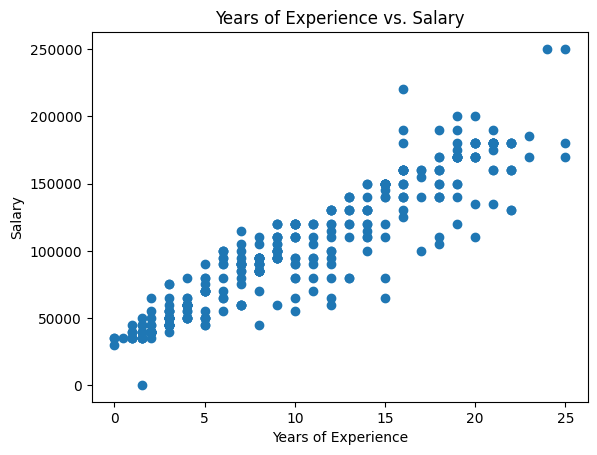

In [71]:
import seaborn as sns

plt.scatter(df['Years of Experience'], df['Salary'])
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Years of Experience vs. Salary')
plt.show()

Spróbuj wykorzystać regresje za pomocą K-NN
https://scikit-learn.org/stable/auto_examples/neighbors/plot_regression.html#sphx-glr-auto-examples-neighbors-plot-regression-py

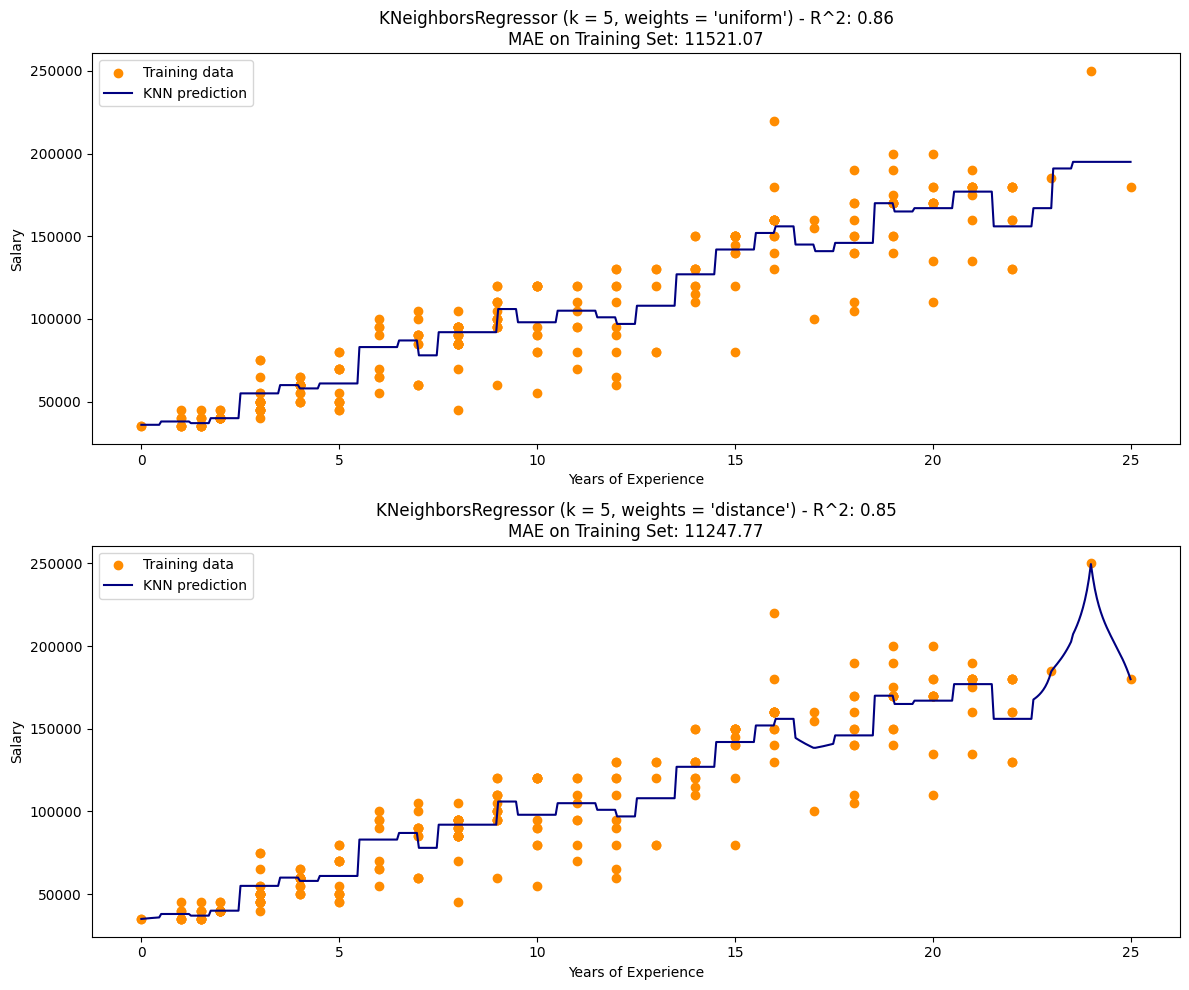

In [75]:
from sklearn import neighbors
import numpy as np

n_neighbors = 5

# Get the range of 'Years of Experience' for creating a smooth prediction line
years_exp_min = df['Years of Experience'].min()
years_exp_max = df['Years of Experience'].max()
X_plot = np.linspace(years_exp_min, years_exp_max, 500).reshape(-1, 1)

plt.figure(figsize=(12, 10)) # Adjust figure size for two plots

for i, weights in enumerate(["uniform", "distance"]):
    # For plotting, we'll train KNN specifically on 'Years of Experience'
    # as the input feature to visualize its effect on Salary.
    # Convert to NumPy array to avoid feature name warning
    X_knn_train = X_train[['Years of Experience']].values
    y_knn_train = y_train

    knn = neighbors.KNeighborsRegressor(n_neighbors, weights=weights)
    knn.fit(X_knn_train, y_knn_train)

    # Predict over the continuous range for plotting the regression line
    y_pred_plot = knn.predict(X_plot)

    # Calculate MAE on the training set
    y_pred_train_knn = knn.predict(X_knn_train)
    mae_train_knn = mean_absolute_error(y_knn_train, y_pred_train_knn)

    # Evaluate the model on the test set using only 'Years of Experience'
    # as the feature, consistent with training. Convert to NumPy array for consistency.
    r2_score_knn = knn.score(X_test[['Years of Experience']].values, y_test)

    plt.subplot(2, 1, i + 1)
    plt.scatter(X_knn_train, y_knn_train, color="darkorange", label="Training data")
    plt.plot(X_plot, y_pred_plot, color="navy", label="KNN prediction")
    plt.xlabel('Years of Experience')
    plt.ylabel('Salary')
    plt.title(f"KNeighborsRegressor (k = {n_neighbors}, weights = '{weights}') - R^2: {r2_score_knn:.2f}\nMAE on Training Set: {mae_train_knn:.2f}")
    plt.legend()
    plt.axis("tight")

plt.tight_layout()
plt.show()

Porównanie wyników błędów na zbiorze testowym:
- model benchmarkowy - regresja liniowa: 11171.01
- model LASSO: 11367.69
- model z kwadratem lat doświadczenia: 11065.23
- model z szcześcianem lat doświadczenia: 11062.48
- metoda knn uniform: 11521.07
- metoda knn distance: 11247.77